In [136]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

# Load CSV file into a Pandas DataFrame
file_path = 'metrics.csv'
df = pd.read_csv(file_path)

In [137]:
df

,train_loss,epoch,step,val_loss,precision_val_ok,precision_val_nok,recall_val_ok,recall_val_nok,fbeta_score_val_ok,fbeta_score_val_nok,...,train_FP,train_FN,omission_rate_train_ok,omission_rate_train_nok,trainc_p_nok,trainc_p_ok,trainc_r_nok,trainc_r_ok,trainc_f_nok,trainc_f_ok
0,0.453149,0,49,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.850908,0,99,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.069307,0,149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.398277,0,199,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.371470,0,249,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1737,0.000108,18,85099,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1738,0.262526,18,85149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1739,0.000199,18,85199,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1740,NaN,18,85233,0.033003,0.993128,0.957164,0.996492,0.919149,0.993799,0.93052,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


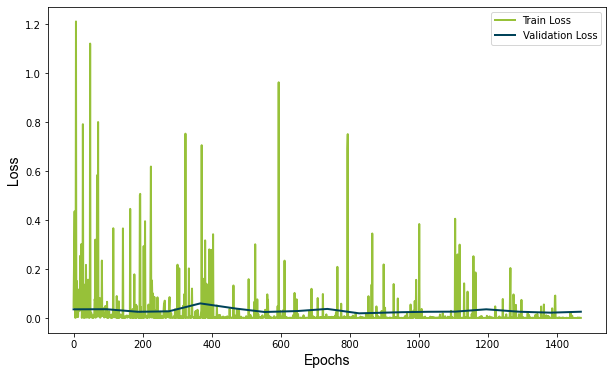

In [130]:
# Train Val Loss Curve

val_loss = []
for i in range(len(df)):
    if df['val_loss'].iloc[i] > 0:
        val_loss.append(df['val_loss'].iloc[i])
        
train_loss = []
for i in range(len(df)):
    if df['val_loss'].iloc[i] > 0:
        train_loss.append(df['train_loss'].iloc[i-1])


plt.figure(figsize=(10, 6))
plt.plot(train_loss, linewidth=2, color='#97C139', label='Train Loss')
plt.plot(val_loss, linewidth=2, color='#004359', label='Validation Loss')
plt.xlabel('Epochs', fontname='Arial', fontsize=14)
plt.ylabel('Loss', fontname='Arial', fontsize=14)
plt.legend()
plt.show()

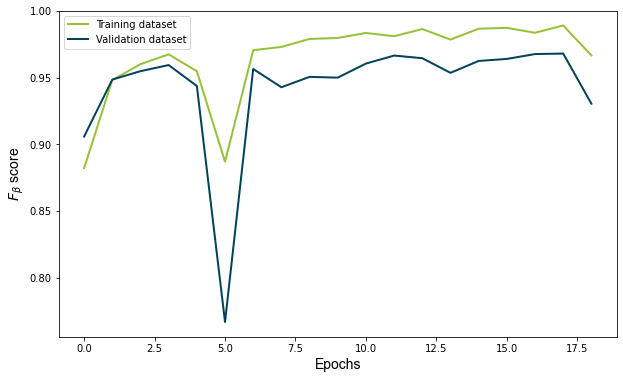

In [138]:
# FBeta Score Curve

fb_score_train = []
fb_score_val = []
for i in range(len(df)):
    if df['fbeta_score_train_nok'].iloc[i] > 0:
        fb_score_train.append(df['fbeta_score_train_nok'].iloc[i])
        
for i in range(len(df)):
    if df['fbeta_score_val_nok'].iloc[i] > 0:
        fb_score_val.append(df['fbeta_score_val_nok'].iloc[i])
        
plt.figure(figsize=(10, 6))
plt.plot(fb_score_train, linewidth=2, color='#97C139', label=r'Training dataset')
plt.plot(fb_score_val, linewidth=2, color='#004359', label=r'Validation dataset')
plt.xlabel('Epochs', fontname='Arial', fontsize=14)
plt.ylabel(r'$F_{\beta}$ score', fontname='Arial', fontsize=14)
plt.legend()
plt.show()

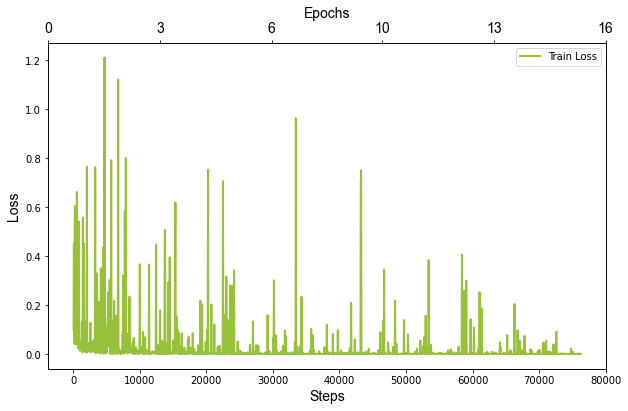

In [122]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming you have a DataFrame 'df' with columns 'step', 'epoch', and 'train_loss'
# Load your data or use your existing DataFrame

# Interpolate missing values for train_loss
df['train_loss'] = df['train_loss'].interpolate()

# Plot train loss with 'step' as the primary x-axis and 'epoch' as the secondary x-axis
plt.figure(figsize=(10, 6))
plt.plot(df['step'], df['train_loss'], linewidth=2, color='#97C139', label='Train Loss')
plt.plot(df['step'], df['val_loss'], linewidth=2, color = '#004359')
plt.xlabel('Steps', fontname='Arial', fontsize=14)
plt.ylabel('Loss', fontname='Arial', fontsize=14)
plt.legend()

# Create secondary x-axis for 'epoch'
secax = plt.twiny()
secax.set_xlabel('Epochs', fontname='Arial', fontsize=14)
secax.set_xlim(df['step'].min(), df['step'].max())
secax.set_xticks(df['step'][::len(df['step']) // 5])  # Adjust the ticks as needed
secax.set_xticklabels(df['epoch'][::len(df['epoch']) // 5], fontname='Arial', fontsize=14)

plt.show()


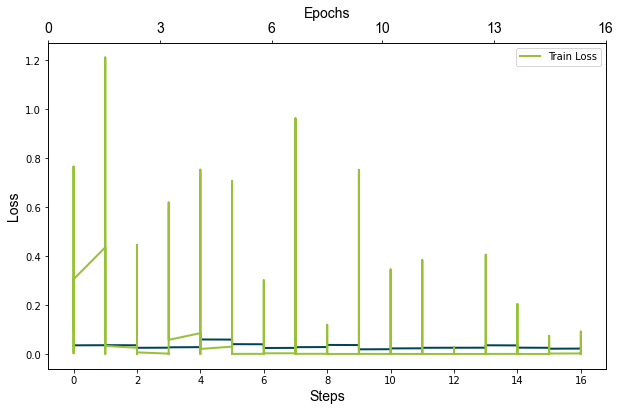

In [128]:
## validation loss

# Interpolate missing values for train_loss
df['val_loss'] = df['val_loss'].interpolate()
# Interpolate missing values for train_loss
df['train_loss'] = df['train_loss'].interpolate()

# Plot train loss with 'step' as primary x-axis and 'epoch' as secondary x-axis
plt.figure(figsize=(10, 6))
plt.plot(df['epoch'], df['val_loss'], linewidth=2, color = '#004359')
plt.plot(df['epoch'], df['train_loss'], linewidth=2, color='#97C139', label='Train Loss')
plt.xlabel('Steps',fontname='Arial', fontsize=14)
plt.ylabel('Loss', fontname='Arial', fontsize=14)
plt.legend()

# Create secondary x-axis for 'epoch'
secax = plt.twiny()
secax.set_xlabel('Epochs',  fontname='Arial', fontsize=14)
secax.set_xlim(df['step'].min(), df['step'].max())
secax.set_xticks(df['step'][::len(df['step']) // 5])  # Adjust the ticks as needed
secax.set_xticklabels(df['epoch'][::len(df['epoch']) // 5],  fontname='Arial', fontsize=14)

plt.show()

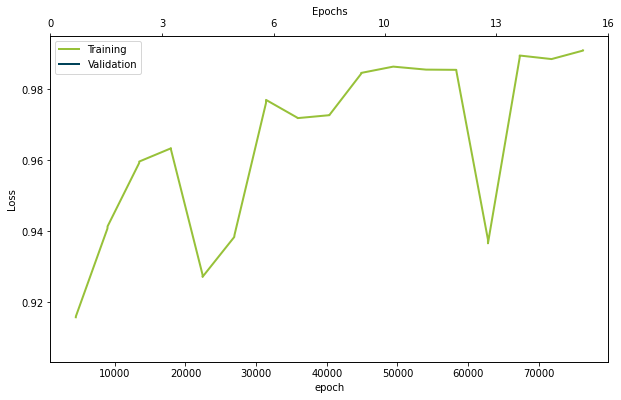

In [124]:
##F1 Score -- training dataset

# Interpolate missing values for train_loss
df['fbeta_score_train_nok'] = df['fbeta_score_train_nok'].interpolate()

# Plot train loss with 'step' as primary x-axis and 'epoch' as secondary x-axis
plt.figure(figsize=(10, 6))
plt.plot(df['step'], df['fbeta_score_train_nok'],  linewidth=2, color='#97C139', label = 'Training')
plt.plot(df['step'], df['fbeta_score_val_nok'], linewidth=2, color= '#004359', label = 'Validation')
plt.xlabel('epoch')
plt.ylabel('Loss')
plt.legend()

# Create secondary x-axis for 'epoch'
secax = plt.twiny()
secax.set_xlabel('Epochs')
secax.set_xlim(df['step'].min(), df['step'].max())
secax.set_xticks(df['step'][::len(df['step']) // 5])  # Adjust the ticks as needed
secax.set_xticklabels(df['epoch'][::len(df['epoch']) // 5])

plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


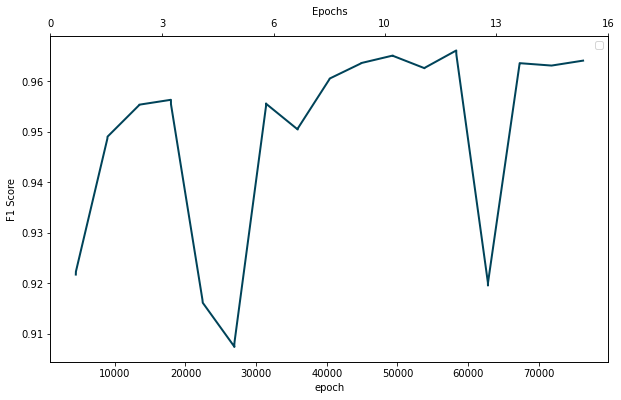

In [125]:
##F1 Score -- Validation dataset



# Interpolate missing values for train_loss
df['fbeta_score_val_nok'] = df['fbeta_score_val_nok'].interpolate()

# Plot train loss with 'step' as primary x-axis and 'epoch' as secondary x-axis
plt.figure(figsize=(10, 6))
plt.plot(df['step'], df['fbeta_score_val_nok'], linewidth=2, color= '#004359')
plt.xlabel('epoch')
plt.ylabel('F1 Score')
plt.legend()

# Create secondary x-axis for 'epoch'
secax = plt.twiny()
secax.set_xlabel('Epochs')
secax.set_xlim(df['step'].min(), df['step'].max())
secax.set_xticks(df['step'][::len(df['step']) // 5])  # Adjust the ticks as needed
secax.set_xticklabels(df['epoch'][::len(df['epoch']) // 5])

plt.show()

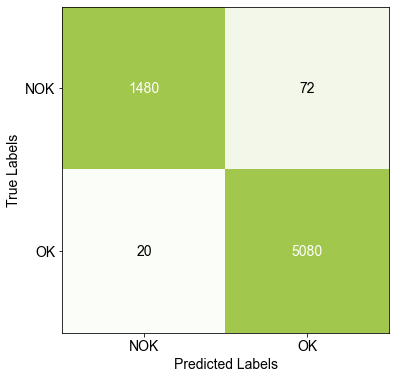

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# Confusion matrix values
conf_matrix = np.array([[1480, 72], 
                       [ 20,  5080]])





# Define RGB colors from hex codes for Class 0 and Class 1
color_class0 = [tuple(int(i, 16)/255 for i in (s[1:3], s[3:5], s[5:7])) for s in ['#FFFFFF']][0]
color_class1 = [tuple(int(i, 16)/255 for i in (s[1:3], s[3:5], s[5:7])) for s in ['#97C139']][0]

# Adjust alpha (transparency) values for contrast
alpha_value_class0 = 0.9  # You can adjust the alpha value (0.0 to 1.0) for Class 0
alpha_value_class1 = 0.9  # You can adjust the alpha value (0.0 to 1.0) for Class 1

# Create colors with adjusted contrast
color_class0_contrast = color_class0 + (alpha_value_class0,)
color_class1_contrast = color_class1 + (alpha_value_class1,)

# Plot confusion matrix as a heatmap with adjusted contrast
cmap_custom = LinearSegmentedColormap.from_list('custom_color', [color_class0_contrast, color_class1_contrast], N=256)

plt.figure(figsize=(8, 6))
plt.imshow([[color_class0_contrast]*conf_matrix.shape[1]]*conf_matrix.shape[0], interpolation='nearest')
img = plt.imshow(conf_matrix, interpolation='nearest', cmap=cmap_custom, vmin=0, vmax=600)  # Adjust vmin and vmax based on your data


classes = ['NOK', 'OK']
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, fontname='Arial', fontsize=14)
plt.yticks(tick_marks, classes, fontname='Arial', fontsize=14)

plt.xlabel('Predicted Labels', fontname='Arial', fontsize=14)
plt.ylabel('True Labels', fontname='Arial', fontsize=14)

# Add text annotations
for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, str(conf_matrix[i, j]), ha='center', va='center', color='white' if conf_matrix[i, j] > 150 else 'black', fontname='Arial', fontsize=14)

plt.show()


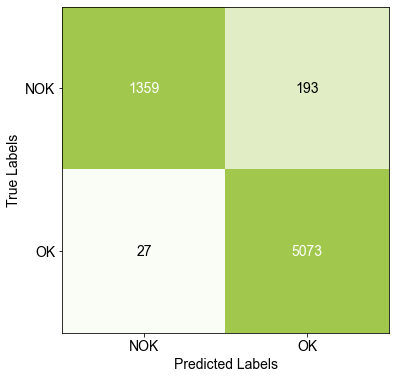

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# Confusion matrix values
conf_matrix = np.array([[1359, 193], 
                       [ 27,  5073]])



# Define RGB colors from hex codes for Class 0 and Class 1
color_class0 = [tuple(int(i, 16)/255 for i in (s[1:3], s[3:5], s[5:7])) for s in ['#FFFFFF']][0]
color_class1 = [tuple(int(i, 16)/255 for i in (s[1:3], s[3:5], s[5:7])) for s in ['#97C139']][0]

# Adjust alpha (transparency) values for contrast
alpha_value_class0 = 0.9  # You can adjust the alpha value (0.0 to 1.0) for Class 0
alpha_value_class1 = 0.9  # You can adjust the alpha value (0.0 to 1.0) for Class 1

# Create colors with adjusted contrast
color_class0_contrast = color_class0 + (alpha_value_class0,)
color_class1_contrast = color_class1 + (alpha_value_class1,)

# Plot confusion matrix as a heatmap with adjusted contrast
cmap_custom = LinearSegmentedColormap.from_list('custom_color', [color_class0_contrast, color_class1_contrast], N=256)

plt.figure(figsize=(8, 6))
plt.imshow([[color_class0_contrast]*conf_matrix.shape[1]]*conf_matrix.shape[0], interpolation='nearest')
img = plt.imshow(conf_matrix, interpolation='nearest', cmap=cmap_custom, vmin=0, vmax=600)  # Adjust vmin and vmax based on your data


classes = ['NOK', 'OK']
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, fontname='Arial', fontsize=14)
plt.yticks(tick_marks, classes, fontname='Arial', fontsize=14)

plt.xlabel('Predicted Labels', fontname='Arial', fontsize=14)
plt.ylabel('True Labels', fontname='Arial', fontsize=14)

# Add text annotations
for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, str(conf_matrix[i, j]), ha='center', va='center', color='white' if conf_matrix[i, j] > 200 else 'black', fontname='Arial', fontsize=14)

plt.show()


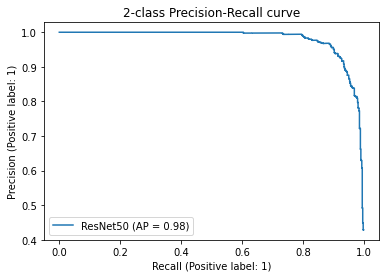

In [64]:
all_labels = np.load("val_labels.npy")
all_predicted_probabilites =  np.load("val_all_probabilities.npy")


display = PrecisionRecallDisplay.from_predictions(
    all_labels,all_predicted_probabilites,  name="ResNet50")
_ = display.ax_.set_title("2-class Precision-Recall curve")

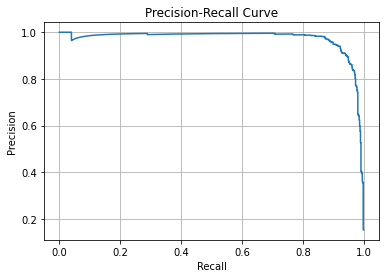

In [50]:
all_labels = np.load("val_all_labels.npy")
all_predicted_probabilities = np.load("val_all_probabilities.npy")


#print(all_predicted_probabilities)
precision, recall, thresholds = precision_recall_curve(all_labels, all_predicted_probabilities)


# Plot the precision-recall curve
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.show()

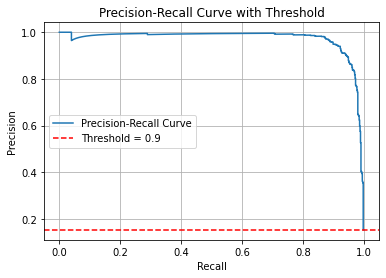

In [76]:
all_labels = np.load("val_all_labels.npy")
all_predicted_probabilities = np.load("val_all_probabilities.npy")


# Set the threshold
threshold = 0.9
# Classify instances based on the threshold
predicted_classes = (all_predicted_probabilities >= threshold).astype(int)

# Compute precision and recall for the positive class using the adjusted predictions
precision, recall, _ = precision_recall_curve(all_labels, all_predicted_probabilities)

# Plot the precision-recall curve
plt.plot(recall, precision, label='Precision-Recall Curve')

# Plot the threshold as a horizontal line
plt.axhline(y=precision[np.searchsorted(recall, threshold)], color='r', linestyle='--', label=f'Threshold = {threshold}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve with Threshold')
plt.legend()
plt.grid(True)
plt.show()

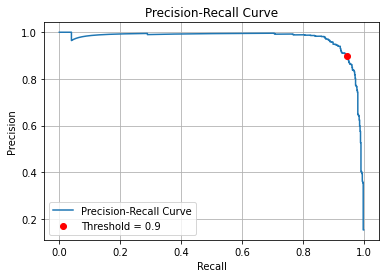

In [79]:

all_labels = np.load("val_all_labels.npy")
all_predicted_probabilities = np.load("val_all_probabilities.npy")

# Define the threshold (you can adjust this)
threshold = 0.9

# Convert predicted probabilities to class labels based on the threshold
predicted_labels = (all_predicted_probabilities >= threshold).astype(int)

# Compute precision and recall for the positive class
precision, recall, _ = precision_recall_curve(all_labels, all_predicted_probabilities)

# Plot the precision-recall curve
plt.plot(recall, precision, label='Precision-Recall Curve')

# Mark the threshold on the curve
plt.scatter(recall[np.searchsorted(precision, threshold)], precision[np.searchsorted(precision, threshold)], c='r', label=f'Threshold = {threshold}', zorder=5)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

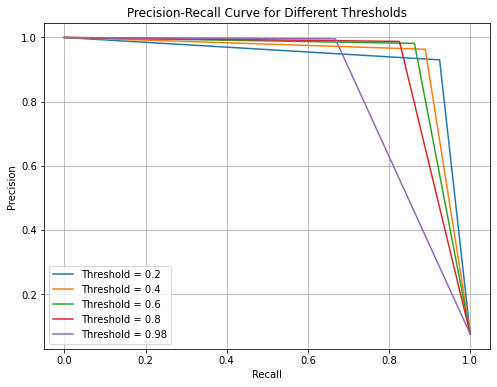

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

# Load data
all_labels = np.load("val_all_labels.npy")
all_predicted_probabilities = np.load("val_all_probabilities.npy")

# Define thresholds
thresholds = [0.2, 0.4, 0.6, 0.8, 0.98]  # Example thresholds

# Initialize lists to store precision and recall values
precision_list = []
recall_list = []

# Compute precision and recall for each threshold
for threshold in thresholds:
    # Compute binary predictions based on threshold
    binary_predictions = (all_predicted_probabilities >= threshold)
    
    # Compute precision and recall
    precision, recall, _ = precision_recall_curve(all_labels, binary_predictions)
    
    # Append precision and recall values to lists
    precision_list.append(precision)
    recall_list.append(recall)

# Plot precision-recall curves for each threshold
plt.figure(figsize=(8, 6))
for i, threshold in enumerate(thresholds):
    plt.plot(recall_list[i], precision_list[i], label=f'Threshold = {threshold}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Different Thresholds')
plt.legend()
plt.grid(True)
plt.show()


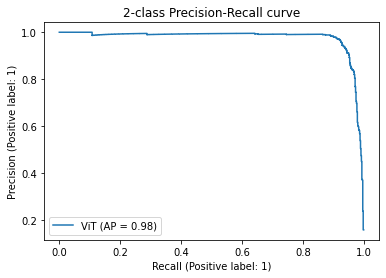

In [63]:
all_labels = np.load("val_all_labels_vit.npy")
all_predicted_probabilites =  np.load("val_all_probabilities_vit.npy")


display = PrecisionRecallDisplay.from_predictions(
    all_labels,all_predicted_probabilites, name="ViT")
_ = display.ax_.set_title("2-class Precision-Recall curve")

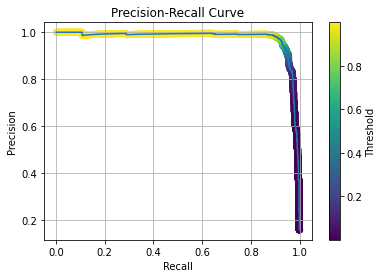

In [69]:
all_labels = np.load("val_all_labels_vit.npy")
all_predicted_probabilities = np.load("val_all_probabilities_vit.npy")


#print(all_predicted_probabilities)
precision, recall, thresholds = precision_recall_curve(all_labels, all_predicted_probabilities)


precision = precision[:-1]
recall = recall[:-1]

# Plot the precision-recall curve
plt.scatter(recall, precision, c=thresholds, cmap='viridis', label='Thresholds')
cbar = plt.colorbar()
cbar.set_label('Threshold')


plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.show()

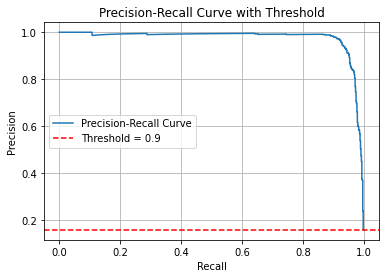

In [75]:
all_labels = np.load("val_all_labels_vit.npy")
all_predicted_probabilities = np.load("val_all_probabilities_vit.npy")


# Set the threshold
threshold = 0.9
# Classify instances based on the threshold
predicted_classes = (all_predicted_probabilities >= threshold).astype(int)

# Compute precision and recall for the positive class using the adjusted predictions
precision, recall, _ = precision_recall_curve(all_labels, all_predicted_probabilities)

# Plot the precision-recall curve
plt.plot(recall, precision, label='Precision-Recall Curve')

# Plot the threshold as a horizontal line
plt.axhline(y=precision[np.searchsorted(recall, threshold)], color='r', linestyle='--', label=f'Threshold = {threshold}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve with Threshold')
plt.legend()
plt.grid(True)
plt.show()

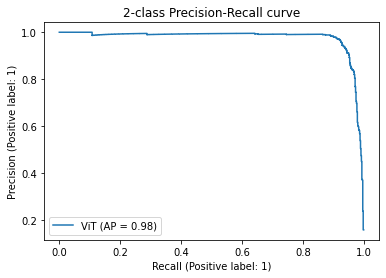

In [80]:
display = PrecisionRecallDisplay.from_predictions(
    all_labels,all_predicted_probabilites, name="ViT")
_ = display.ax_.set_title("2-class Precision-Recall curve")

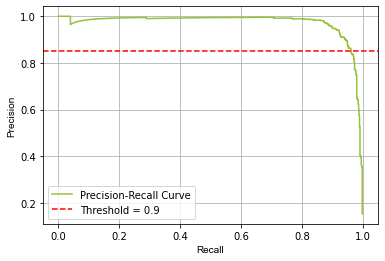

In [140]:
all_labels = np.load("val_all_labels.npy")
all_predicted_probabilites =  np.load("val_all_preds.npy")


'''display = PrecisionRecallDisplay.from_predictions(
    all_labels,all_predicted_probabilites, name="ViT")
_ = display.ax_.set_title("2-class Precision-Recall curve")'''


# Classify instances based on the threshold
predicted_classes = (all_predicted_probabilities >= threshold).astype(int)

# Compute precision and recall for the positive class using the adjusted predictions
precision, recall, _ = precision_recall_curve(all_labels, all_predicted_probabilities)

# Plot the precision-recall curve
plt.plot(recall, precision, color='#97C139', label='Precision-Recall Curve')

# Find the index of the closest threshold value to the chosen threshold
closest_index = np.argmin(np.abs(thresholds - threshold))

# Plot the threshold as a horizontal line
plt.axhline(y=precision[closest_index], color='r', linestyle='--', label='Threshold = 0.9')

plt.xlabel('Recall', fontname='Arial')
plt.ylabel('Precision', fontname='Arial')
plt.legend()
plt.grid(True)
plt.show()

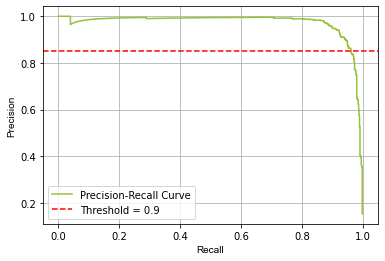

In [139]:
all_labels = np.load("val_all_labels_vit.npy")
all_predicted_probabilites =  np.load("val_all_probabilities_vit.npy")
# Set the threshold
# Set the threshold
threshold = 0.9

# Classify instances based on the threshold
predicted_classes = (all_predicted_probabilities >= threshold).astype(int)

# Compute precision and recall for the positive class using the adjusted predictions
precision, recall, _ = precision_recall_curve(all_labels, all_predicted_probabilities)

# Plot the precision-recall curve
plt.plot(recall, precision, color='#97C139', label='Precision-Recall Curve')

# Find the index of the closest threshold value to the chosen threshold
closest_index = np.argmin(np.abs(thresholds - threshold))

# Plot the threshold as a horizontal line
plt.axhline(y=precision[closest_index], color='r', linestyle='--', label='Threshold = 0.9')

plt.xlabel('Recall', fontname='Arial')
plt.ylabel('Precision', fontname='Arial')
plt.legend()
plt.grid(True)
plt.show()
